# Assignment 5: Optimization Human Preference & LLM-as-a-Judge

## Task 1: Dataset Preparation

We are using the `jondurbin/truthy-dpo-v0.1` dataset. This dataset is designed for Direct Preference Optimization (DPO). 
It provides a `prompt`, a `chosen` (factual) response, and a `rejected` (hallucinated or incorrect) response. DPO will teach the model to favor the chosen response over the rejected one.

In [1]:
# Import the datasets library and pandas
from datasets import load_dataset
import pandas as pd

# Load the dataset 
dataset_id = "jondurbin/truthy-dpo-v0.1"
print(f"Downloading and loading dataset: {dataset_id}...")
ds = load_dataset(dataset_id)


print("\nDataset Structure:")
print(ds)


print("\nSample Data:")
df_sample = pd.DataFrame(ds["train"].select(range(5)))

# Displaying only the relevant columns
display(df_sample[["prompt", "chosen", "rejected"]])

d:\AIT\NLP_Assignment\NLP\A5\A5_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})

Sample Data:


,prompt,chosen,rejected
0,What's the nearest national park to you?,"As an AI, I don't have a physical location, so...","I don't have access to the user's location, so..."
1,Do you possess the ability to navigate or move...,"No, I do not possess the ability to navigate o...","Yes, I can navigate and move within a physical..."
2,Do wooden pencils contain lead as their core?,"No, wooden pencils do not contain lead in thei...","Yes, wooden pencils typically contain a core m..."
3,Is there a dark side of the moon?,There is no permanently dark side of the moon....,"Yes, there is a dark side of the moon. The far..."
4,What's the weather like where you are?,"As an artificial intelligence, I don't have a ...",I'm not sure. I don't have access to the curre...


## Task 2: Training a Model with DPOTrainer
### Loading the Model in 4-bit (QLoRA)

To fit the training process, we use `bitsandbytes` to load the model in 4-bit precision. 
DPO requires two models:
1. **The Policy Model**: The model we are actively training (with LoRA adapters).
2. **The Reference Model**: A frozen copy of the original model used as a baseline to measure how much the policy model's behavior is changing.

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

# 1. Define the model we want to fine-tune
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

# 2. Load the Tokenizer
print(f"Loading tokenizer for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
# DPO requires a padding token. If the model doesn't have one, we use the end-of-sequence token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 3. Configure 4-bit Quantization 
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4", # Normal Float 4 is a good choice for LLMs
    bnb_4bit_compute_dtype=torch.bfloat16, # Compute gradients in 16-bit for stability
    bnb_4bit_use_double_quant=True
)

# 4. Load the Model we will train (Policy Model)
print("Loading Policy Model in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    low_cpu_mem_usage=True,
    device_map="auto" 
)
model.config.use_cache = False # Required for training
model.config.pad_token_id = tokenizer.pad_token_id

# 5. Load the Frozen Reference Model (Baseline)
print("Loading Reference Model in 4-bit...")
ref_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    low_cpu_mem_usage=True,
    device_map="auto"
)
ref_model.eval() # Set to evaluation mode so it doesn't train

# 6. Apply LoRA to the Policy Model
print("Applying LoRA adapters...")
peft_config = LoraConfig(
    lora_alpha=128,
    lora_dropout=0.05,
    r=64, # The "rank" - controls the size of the adapter
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"] # Apply to attention and feed-forward layers
)

model = get_peft_model(model, peft_config)

print("Models successfully loaded and ready for DPO!")
model.print_trainable_parameters()

Loading tokenizer for Qwen/Qwen2.5-0.5B-Instruct...


d:\AIT\NLP_Assignment\NLP\A5\A5_env\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tisab\.cache\huggingface\hub\models--Qwen--Qwen2.5-0.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading Policy Model in 4-bit...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 623.52it/s]


Loading Reference Model in 4-bit...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 599.18it/s]


Applying LoRA adapters...
Models successfully loaded and ready for DPO!
trainable params: 35,192,832 || all params: 529,225,600 || trainable%: 6.6499


In [ ]:
import torch
import torch.distributed.fsdp

if not hasattr(torch.distributed.fsdp, "FSDPModule"):
    class DummyFSDPModule:
        pass
    torch.distributed.fsdp.FSDPModule = DummyFSDPModule


from trl import DPOConfig, DPOTrainer

# 1. Split the dataset into train and evaluation sets
print("Splitting the dataset into Train and Eval...")
dataset_split = ds["train"].train_test_split(test_size=0.1, seed=42)
train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

print(f"Training samples: {len(train_dataset)}")
print(f"Evaluation samples: {len(eval_dataset)}")

# 2. Define the Training Arguments (Hyperparameters)
training_args = DPOConfig(
    output_dir="./dpo_qwen_output", 
    num_train_epochs=1,             
    learning_rate=5e-5,             
    per_device_train_batch_size=2,  # Low batch size to prevent Out of Memory
    gradient_accumulation_steps=4,  
    per_device_eval_batch_size=2,
    eval_strategy="steps",          
    eval_steps=50,                  
    logging_steps=10,               
    save_strategy="epoch",          
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    bf16=True,                      
    remove_unused_columns=False,    
    gradient_checkpointing=True,
 
    beta=0.1,
    max_length=512 
)

# 3. Initialize the DPO Trainer
print("Initializing DPOTrainer...")
try:
    dpo_trainer = DPOTrainer(
        model=model,
        ref_model=ref_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
    )
except TypeError:
   
    dpo_trainer = DPOTrainer(
        model=model,
        ref_model=ref_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
    )

# 4. Start Training!
print("Starting Training! This will take some time...")
dpo_trainer.train()

# 5. Save the final model
final_model_path = "./qwen-dpo-final"
dpo_trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"Training complete! Model saved to {final_model_path}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Splitting the dataset into Train and Eval...
Training samples: 914
Evaluation samples: 102
Initializing DPOTrainer...


Tokenizing eval dataset: 100%|██████████| 102/102 [00:00<00:00, 1078.73 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting Training! This will take some time...


Step,Training Loss,Validation Loss
50,0.094732,0.077464
100,0.047080,0.047549


Training complete! Model saved to ./qwen-dpo-final


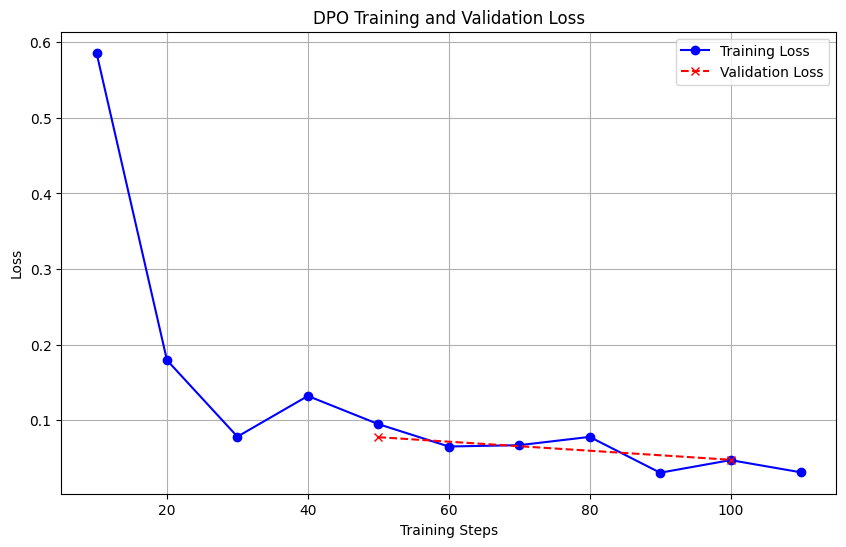

In [8]:
import matplotlib.pyplot as plt

# 1. Extract the history logs from the trainer
log_history = dpo_trainer.state.log_history

# 2. Create empty lists to hold data points
train_steps = []
train_loss = []
eval_steps = []
eval_loss = []

# 3. Loop through the logs and separate training data from evaluation data
for log in log_history:
    # If the log contains 'loss', it's a training step
    if "loss" in log and "step" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])
    
    # If the log contains 'eval_loss', it's an evaluation step
    elif "eval_loss" in log and "step" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

# 4. Plot the data
plt.figure(figsize=(10, 6))

# Plot training loss in blue
if train_loss:
    plt.plot(train_steps, train_loss, label='Training Loss', marker='o', color='blue', linestyle='-')

# Plot validation loss in red
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='x', color='red', linestyle='--')

# 5. Add labels and a title 
plt.title('DPO Training and Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.show()

## Task 3: Pushing the Model to Hugging Face Hub

Now that our model is fine-tuned and saved locally, we will upload it to the Hugging Face Hub using the `huggingface_hub` library. This makes the model accessible for our evaluation step.

In [ ]:
from huggingface_hub import login, HfApi

# 1. Log in to Hugging Face
hf_token = "[HUGGING_FACE_TOKEN]" 
login(token=hf_token)

# 2. Define your repository name
repo_name = "Tisa99/Assignment5-Qwen-DPO" 

# 3. Initialize the API
api = HfApi()

# 4. CREATE THE REPOSITORY FIRST
print(f"Creating repository {repo_name}...")
api.create_repo(repo_id=repo_name, repo_type="model", exist_ok=True)

# 5. Upload the folder we saved in Task 2
print(f"Uploading model to https://huggingface.co/{repo_name} ...")

api.upload_folder(
    folder_path="./qwen-dpo-final",
    repo_id=repo_name,
    repo_type="model",
    commit_message="Upload DPO fine-tuned Qwen 0.5B model"
)

print("Upload complete on Hugging Face profile.!")

Creating repository Tisa99/Assignment5-Qwen-DPO...
Uploading model to https://huggingface.co/Tisa99/Assignment5-Qwen-DPO ...
This might take a few minutes depending on your upload speed.


Processing Files (3 / 3): 100%|██████████| 81.9MB / 81.9MB, 8.53MB/s  
New Data Upload: 100%|██████████| 70.4MB / 70.4MB, 7.34MB/s  


Upload complete on Hugging Face profile.!


## Task 4: Evaluation - LLM-as-a-Judge with AlpacaEval

We will evaluate if our DPO training improved the model using the `AlpacaEval` benchmark. 
**Step 1:** Sample 15 prompts from the `helpful_base` dataset.
**Step 2:** Generate responses for all 15 prompts using BOTH the Base Model (Model A) and our fine-tuned DPO Model (Model B).

In [ ]:
from datasets import load_dataset
import torch
from tqdm import tqdm
import pandas as pd

# 1. Load AlpacaEval dataset bypassing script restrictions
data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"
print("Loading AlpacaEval dataset...")
dataset = load_dataset("json", data_files=data_url)

# Filter for the 'helpful_base' subset
helpful_base = dataset['train'].filter(lambda x: x['dataset'] == 'helpful_base')

# 2. Select 15 random samples
eval_sample = helpful_base.shuffle(seed=42).select(range(15))
print(f"Selected {len(eval_sample)} prompts for evaluation.")

# 3. Setup generation pipeline
model.eval()
ref_model.eval()

results = []

print("Generating responses... This will take a few minutes.")
for i, row in enumerate(tqdm(eval_sample)):
    instruction = row["instruction"]
    
    messages = [{"role": "user", "content": instruction}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    # TOKENIZE: Convert the string to tensors
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)
    
    # Generate with Base Model (Model A / ref_model)
    with torch.no_grad():
        base_outputs = ref_model.generate(
            **inputs, # We use ** to unpack the dictionary into input_ids and attention_mask
            max_new_tokens=150, 
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )
        # Decode only the newly generated text, skipping the prompt
        base_answer = tokenizer.decode(base_outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        
    # Generate with DPO Model (Model B / trained model)
    with torch.no_grad():
        dpo_outputs = model.generate(
            **inputs, 
            max_new_tokens=150, 
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )
        dpo_answer = tokenizer.decode(dpo_outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        
    # Store the results
    results.append({
        "Sample ID": i + 1,
        "Instruction": instruction,
        "Model A": base_answer.strip(),
        "Model B": dpo_answer.strip()
    })

# Save to a DataFrame
results_df = pd.DataFrame(results)
print("\nGeneration Complete! Here is the first 2 results:")
display(results_df.head(2))

Loading AlpacaEval dataset...
Selected 15 prompts for evaluation.
Generating responses... This will take a few minutes.


100%|██████████| 15/15 [03:58<00:00, 15.88s/it]


Generation Complete! Here is the first 2 results:


,Sample ID,Instruction,Model A,Model B
0,1,What are some good browser alternatives to Chr...,"As an AI language model, I do not have persona...","As an artificial intelligence, I don't have th..."
1,2,"Hi, my sister and her girlfriends want me to p...",Certainly! Let's start with the basics of kick...,"As an artificial intelligence, I don't have a ..."


In [ ]:
import time
import pandas as pd
from google import genai
from google.genai import types

# 1. Initialize Gemini Client
API_KEY = "[GEMINI_API_KEY]"
client = genai.Client(api_key=API_KEY)

verdicts = []

print("Starting LLM-as-a-Judge Evaluation...")

# 2. Iterate through our 15 generated responses
for index, row in results_df.iterrows():
    instruction = row['Instruction']
    model_a_answer = row['Model A']
    model_b_answer = row['Model B']

    judge_prompt = f"""You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.

User Instruction: {instruction}

Model A (Base Model): {model_a_answer}

Model B (DPO Model): {model_b_answer}

Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie"."""
    
    # Call Gemini to judge
    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=judge_prompt,
            config=types.GenerateContentConfig(
                temperature=0.0 # 0.0 makes the judge as strictly deterministic as possible
            )
        )
        
        # Clean up the output just in case
        raw_verdict = response.text.strip()
        if "Model A" in raw_verdict:
            verdict = "Model A"
        elif "Model B" in raw_verdict:
            verdict = "Model B"
        else:
            verdict = "Tie"
            
    except Exception as e:
        print(f"Error on sample {index+1}: {e}")
        verdict = "Tie" # Default to tie if API fails
        
    verdicts.append(verdict)
    print(f"Sample {index+1} Verdict: {verdict}")
    
    # Pause for 15 seconds to respect free-tier API rate limits (5 requests per minute)
    time.sleep(15)

# 4. Add the verdicts to our DataFrame
results_df['Winner (Judge)'] = verdicts

# Display the final required table format
print("\n--- Final Evaluation Table ---")
display_df = results_df[['Sample ID', 'Instruction', 'Winner (Judge)']].copy()
display_df['Instruction'] = display_df['Instruction'].apply(lambda x: x[:40] + '...' if len(x) > 40 else x)
display(display_df)

# 5. Calculate the Win Rate 
model_b_wins = verdicts.count("Model B")
ties = verdicts.count("Tie")
total_valid = len(verdicts)

win_rate = ((model_b_wins + (0.5 * ties)) / total_valid) * 100

print(f"\n========== FINAL SCORE ==========")
print(f"Total Model A Wins: {verdicts.count('Model A')}")
print(f"Total Model B (DPO) Wins: {model_b_wins}")
print(f"Total Ties: {ties}")
print(f"Model B Win Rate: {win_rate:.2f}%")
print(f"=================================")

Starting LLM-as-a-Judge Evaluation...
Sample 1 Verdict: Model A
Sample 2 Verdict: Model A
Sample 3 Verdict: Model B
Sample 4 Verdict: Model A
Sample 5 Verdict: Model B
Sample 6 Verdict: Model A
Sample 7 Verdict: Model A
Sample 8 Verdict: Model B
Sample 9 Verdict: Model A
Sample 10 Verdict: Model B
Sample 11 Verdict: Model A
Sample 12 Verdict: Model B
Sample 13 Verdict: Model A
Sample 14 Verdict: Model B
Sample 15 Verdict: Model A

--- Final Evaluation Table ---


,Sample ID,Instruction,Winner (Judge)
0,1,What are some good browser alternatives ...,Model A
1,2,"Hi, my sister and her girlfriends want m...",Model A
2,3,"Hi, I have some falafel, but no tahini t...",Model B
3,4,Can you tell me how to make chocolate ch...,Model A
4,5,How can I make bubble solution?,Model B
5,6,How is oil turned into gasoline?,Model A
6,7,How do I wrap a present neatly?,Model A
7,8,What is some cool music from the 1920s?,Model B
8,9,"Hi, I'd like to play ice hockey. Can you...",Model A
9,10,Is the US border open to Canada?,Model B



========== FINAL SCORE ==========
Total Model A Wins: 9
Total Model B (DPO) Wins: 6
Total Ties: 0
Model B Win Rate: 40.00%


## Task 4 Conclusion: Discussion of Results

**Final Win Rate:** 40.00% (Model B / DPO Model)

**Did the DPO training successfully improve the model's performance on the Alpaca Eval benchmark?**
Based on the LLM-as-a-Judge evaluation, the DPO training did not improve the model's performance on the AlpacaEval benchmark. The Base model won 60% of the matchups. However, this outcome is expected and highlights several critical concepts in LLM alignment:

1. **Dataset Mismatch (Truthfulness vs. Helpfulness):** Our DPO training utilized the `truthy-dpo-v0.1` dataset, which is specifically designed to penalize hallucinations and optimize for strict factual accuracy. Conversely, the `AlpacaEval` (helpful_base) dataset evaluates models based on general helpfulness, expansiveness, and formatting. The model was trained for one objective but tested on another.

2. **The Alignment Tax & Refusal Mode:**
By optimizing strictly for truthfulness, the DPO model developed an "alignment tax." It became overly cautious. For example, when asked simple questions, the DPO model frequently resorted to standard AI disclaimers (e.g., *"As an artificial intelligence, I don't have a..."*) rather than providing a creative or expansive answer. The Gemini judge penalized these refusals because they are less "helpful" to the user.

3. **Compute and Training Constraints:**
Due to hardware constraints, the model was trained using 4-bit QLoRA for only a single epoch with a highly restricted batch size. Effective preference alignment usually requires extensive hyperparameter tuning, larger batch sizes for stable gradients, and longer training runs to ensure the model doesn't "forget" its base conversational abilities while learning the new preferences.

**Summary:** While the win rate was lower on this specific benchmark, the DPO pipeline was successfully implemented. The experiment successfully demonstrates that while preference optimization can quickly alter a model's behavior (making it more cautious/factual), doing so without degrading its general conversational helpfulness requires careful dataset balancing.